## Requirements

### Dependencies

### Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from statistics import mode, StatisticsError

## Feature Extraction Pipeline

In [9]:
def extract_payload_length(info_string):
    """Extract payload length from Info column"""
    if pd.isna(info_string):
        return 0
    info_str = str(info_string)
    # Look for "Len=" in the Info field
    if "Len=" in info_str:
        try:
            # Extract the number after "Len="
            len_idx = info_str.find("Len=")
            len_str = info_str[len_idx+4:].split()[0]
            return int(len_str)
        except:
            return 0
    return 0


def extract_features(df_session):
    """
    Extract network traffic features from a session dataframe.
    
    Parameters:
    df_session: DataFrame with columns 'Time' and 'Length'
    
    Returns:
    Dictionary containing all extracted features
    """
    features = {}
    
    # 1. Packet count
    features['packet_count'] = len(df_session)
    
    # 2. Total length
    features['total_length'] = df_session['Length'].sum()
    
    # Packet intervals
    if len(df_session) > 1:
        time_diffs = df_session['Time'].diff().dropna().values
        features['avg_packet_interval'] = time_diffs.mean()
        features['max_packet_interval'] = time_diffs.max()
        
        # Most common packet interval
        try:
            features['most_common_packet_interval'] = mode(time_diffs)
        except StatisticsError:
            features['most_common_packet_interval'] = np.nan
    else:
        features['avg_packet_interval'] = 0
        features['max_packet_interval'] = 0
        features['most_common_packet_interval'] = 0
    
    # Packet length statistics
    features['avg_packet_length'] = df_session['Length'].mean()
    features['max_packet_length'] = df_session['Length'].max()
    features['min_packet_length'] = df_session['Length'].min()
    
    # Most common packet length
    try:
        features['most_common_packet_length'] = mode(df_session['Length'].values)
    except StatisticsError:
        # If there's no mode (all unique), use 0 or NaN
        features['most_common_packet_length'] = np.nan
    
    # Payload and header statistics
    df_session['payload_length'] = df_session['Info'].apply(extract_payload_length)
    features['avg_payload_length'] = df_session['payload_length'].mean()
    
    df_session['header_length'] = df_session['Length'] - df_session['payload_length']
    features['avg_header_length'] = df_session['header_length'].mean()
    
    return features


def load_and_process_sessions(data_dir='data'):
    """
    Load all network session CSV files matching pattern networkname_number.csv
    and extract features for each session.
    
    Parameters:
    data_dir: Directory containing the CSV files
    
    Returns:
    DataFrame with one row per session and columns for each feature
    """
    data_path = Path(data_dir)
    csv_files = sorted(data_path.glob('*_*.csv'))
    
    all_features = []
    
    for csv_file in csv_files:
        try:
            # Load the session
            df = pd.read_csv(csv_file)
            
            # Extract network name and session number from filename
            filename = csv_file.stem  # removes .csv extension
            parts = filename.rsplit('_', 1)  # split from the right on last _
            if len(parts) == 2:
                network_name, session_num = parts
            else:
                network_name = filename
                session_num = None
            
            # Convert Time column to numeric and sort by time
            df['Time'] = pd.to_numeric(df['Time'])
            df = df.sort_values('Time').reset_index(drop=True)
            
            # Extract features
            features = extract_features(df)
            features['network'] = network_name
            features['session'] = session_num
            
            all_features.append(features)
            print(f"Processed: {csv_file.name}")
            
        except Exception as e:
            print(f"Error processing {csv_file.name}: {e}")
    
    # Create DataFrame from all features
    features_df = pd.DataFrame(all_features)
    return features_df


# Load and process all sessions
df_features = load_and_process_sessions('data')

Processed: colonialwilliamsburg_01.csv
Processed: colonialwilliamsburg_02.csv
Processed: colonialwilliamsburg_03.csv
Processed: colonialwilliamsburg_04.csv
Processed: colonialwilliamsburg_05.csv
Processed: colonialwilliamsburg_06.csv
Processed: colonialwilliamsburg_07.csv
Processed: colonialwilliamsburg_08.csv
Processed: colonialwilliamsburg_09.csv
Processed: colonialwilliamsburg_10.csv
Processed: colonialwilliamsburg_11.csv
Processed: colonialwilliamsburg_12.csv
Processed: colonialwilliamsburg_13.csv
Processed: colonialwilliamsburg_14.csv
Processed: colonialwilliamsburg_15.csv
Processed: colonialwilliamsburg_16.csv
Processed: colonialwilliamsburg_17.csv
Processed: colonialwilliamsburg_18.csv
Processed: colonialwilliamsburg_19.csv
Processed: colonialwilliamsburg_20.csv
Processed: instagram_01.csv
Processed: instagram_02.csv
Processed: instagram_03.csv
Processed: instagram_04.csv
Processed: instagram_05.csv
Processed: instagram_06.csv
Processed: instagram_07.csv
Processed: instagram_08.

In [10]:
df_features.to_csv("data/packet_data.csv", index=False)

In [11]:
df_features.head()

,packet_count,total_length,avg_packet_interval,max_packet_interval,most_common_packet_interval,avg_packet_length,max_packet_length,min_packet_length,most_common_packet_length,avg_payload_length,avg_header_length,network,session
0,798,378701,0.073880,6.060027,1.000000e-06,474.562657,1514,54,66,214.834586,259.728070,colonialwilliamsburg,01
1,554,231689,0.091706,5.009707,3.000000e-06,418.211191,1514,54,66,245.261733,172.949458,colonialwilliamsburg,02
2,559,234630,0.105295,10.030999,3.000000e-06,419.731664,1514,54,66,251.377460,168.354204,colonialwilliamsburg,03
3,231,70556,0.240017,11.117093,3.000000e-06,305.437229,1514,54,66,143.528139,161.909091,colonialwilliamsburg,04
4,93,14414,0.587726,11.968261,3.000000e-06,154.989247,1454,54,66,30.182796,124.806452,colonialwilliamsburg,05


In [14]:
X = df_features.drop(columns=['network', 'session'])
y = df_features['network']

# Splitting Datasets

In [7]:
from sklearn.model_selection import train_test_split

In [15]:
# 6:2:2 split with balanced network source distribution
# currently set with random state seed of 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain network distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation network distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest network distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (36, 11)
Validation shape: (12, 11)
Test shape: (12, 11)

Train network distribution:
network
target                  0.333333
colonialwilliamsburg    0.333333
instagram               0.333333
Name: proportion, dtype: float64

Validation network distribution:
network
target                  0.333333
instagram               0.333333
colonialwilliamsburg    0.333333
Name: proportion, dtype: float64

Test network distribution:
network
colonialwilliamsburg    0.333333
target                  0.333333
instagram               0.333333
Name: proportion, dtype: float64


In [17]:
X.columns

Index(['packet_count', 'total_length', 'avg_packet_interval',
       'max_packet_interval', 'most_common_packet_interval',
       'avg_packet_length', 'max_packet_length', 'min_packet_length',
       'most_common_packet_length', 'avg_payload_length', 'avg_header_length'],
      dtype='str')

In [18]:
import seaborn as sns

import matplotlib.pyplot as plt

## Model Testing and Comparison Framework

In [20]:
# Model imports and preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Initialize results storage
model_results = {}

In [21]:
# Evaluation utilities
def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name):
    """
    Comprehensive model evaluation on train, validation, and test sets.
    
    Returns dictionary with all metrics for comparison.
    """
    results = {
        'model': model_name,
        'train': {},
        'validation': {},
        'test': {}
    }
    
    # Evaluate on each set
    for set_name, (X, y) in [('train', (X_train, y_train)), 
                              ('validation', (X_val, y_val)), 
                              ('test', (X_test, y_test))]:
        y_pred = model.predict(X)
        
        results[set_name]['accuracy'] = accuracy_score(y, y_pred)
        results[set_name]['precision_weighted'] = precision_score(y, y_pred, average='weighted', zero_division=0)
        results[set_name]['recall_weighted'] = recall_score(y, y_pred, average='weighted', zero_division=0)
        results[set_name]['f1_weighted'] = f1_score(y, y_pred, average='weighted', zero_division=0)
        results[set_name]['f1_macro'] = f1_score(y, y_pred, average='macro', zero_division=0)
    
    return results

def print_model_results(results):
    """Pretty print model evaluation results"""
    model_name = results['model']
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    
    for set_name in ['train', 'validation', 'test']:
        print(f"\n{set_name.upper()} SET:")
        for metric, value in results[set_name].items():
            print(f"  {metric:20s}: {value:.4f}")


### 1. Random Forest Classifier

In [22]:
# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Evaluate Random Forest
rf_results = evaluate_model(rf_model, X_train, X_val, X_test, y_train, y_val, y_test, "Random Forest")
model_results['Random Forest'] = rf_results
print_model_results(rf_results)

# Feature importance
print("\nTop 10 Most Important Features (Random Forest):")
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_importance.head(10))

Training Random Forest...

Model: Random Forest

TRAIN SET:
  accuracy            : 1.0000
  precision_weighted  : 1.0000
  recall_weighted     : 1.0000
  f1_weighted         : 1.0000
  f1_macro            : 1.0000

VALIDATION SET:
  accuracy            : 0.9167
  precision_weighted  : 0.9333
  recall_weighted     : 0.9167
  f1_weighted         : 0.9153
  f1_macro            : 0.9153

TEST SET:
  accuracy            : 0.9167
  precision_weighted  : 0.9333
  recall_weighted     : 0.9167
  f1_weighted         : 0.9153
  f1_macro            : 0.9153

Top 10 Most Important Features (Random Forest):
max_packet_length              0.176962
most_common_packet_interval    0.148833
avg_packet_length              0.139422
avg_packet_interval            0.133789
packet_count                   0.120879
most_common_packet_length      0.116838
min_packet_length              0.073604
avg_header_length              0.033179
total_length                   0.031351
avg_payload_length             0.02279

### 2. Logistic Regression (Multiclass)

In [23]:
# Scale features for Logistic Regression
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)
X_test_scaled = scaler_lr.transform(X_test)

print("Training Logistic Regression (Multiclass)...")
lg_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lg_model.fit(X_train_scaled, y_train)

# Evaluate Logistic Regression
lg_results = evaluate_model(lg_model, X_train_scaled, X_val_scaled, X_test_scaled, 
                            y_train, y_val, y_test, "Logistic Regression")
model_results['Logistic Regression'] = lg_results
print_model_results(lg_results)

Training Logistic Regression (Multiclass)...

Model: Logistic Regression

TRAIN SET:
  accuracy            : 1.0000
  precision_weighted  : 1.0000
  recall_weighted     : 1.0000
  f1_weighted         : 1.0000
  f1_macro            : 1.0000

VALIDATION SET:
  accuracy            : 0.9167
  precision_weighted  : 0.9333
  recall_weighted     : 0.9167
  f1_weighted         : 0.9153
  f1_macro            : 0.9153

TEST SET:
  accuracy            : 0.9167
  precision_weighted  : 0.9333
  recall_weighted     : 0.9167
  f1_weighted         : 0.9153
  f1_macro            : 0.9153


### 3. Support Vector Machine (SVM)

In [24]:
# SVM also needs scaled features
print("Training Support Vector Machine (SVM)...")
svm_model = SVC(
    kernel='rbf',  # RBF kernel generally works well
    C=1.0,
    gamma='scale',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

# Evaluate SVM
svm_results = evaluate_model(svm_model, X_train_scaled, X_val_scaled, X_test_scaled, 
                             y_train, y_val, y_test, "Support Vector Machine")
model_results['Support Vector Machine'] = svm_results
print_model_results(svm_results)

Training Support Vector Machine (SVM)...

Model: Support Vector Machine

TRAIN SET:
  accuracy            : 1.0000
  precision_weighted  : 1.0000
  recall_weighted     : 1.0000
  f1_weighted         : 1.0000
  f1_macro            : 1.0000

VALIDATION SET:
  accuracy            : 0.9167
  precision_weighted  : 0.9333
  recall_weighted     : 0.9167
  f1_weighted         : 0.9153
  f1_macro            : 0.9153

TEST SET:
  accuracy            : 0.8333
  precision_weighted  : 0.8667
  recall_weighted     : 0.8333
  f1_weighted         : 0.8148
  f1_macro            : 0.8148


### 4. TensorFlow/Keras Neural Network

In [25]:
# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

print("TensorFlow version:", tf.__version__)

# Encode labels for neural network
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Convert to categorical (one-hot encoding)
y_train_cat = keras.utils.to_categorical(y_train_encoded, num_classes=len(label_encoder.classes_))
y_val_cat = keras.utils.to_categorical(y_val_encoded, num_classes=len(label_encoder.classes_))
y_test_cat = keras.utils.to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

print(f"\nNumber of classes: {len(label_encoder.classes_)}")
print(f"Classes: {label_encoder.classes_}")
print(f"y_train_cat shape: {y_train_cat.shape}")

# Build neural network model
print("\nBuilding Neural Network Model...")
nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(nn_model.summary())

TensorFlow version: 2.19.1

Number of classes: 3
Classes: ['colonialwilliamsburg' 'instagram' 'target']
y_train_cat shape: (36, 3)

Building Neural Network Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,971 (46.76 KB)

 Trainable params: 11,971 (46.76 KB)

 Non-trainable params: 0 (0.00 B)

None


In [26]:
# Train neurał network
print("Training Neural Network...")
history = nn_model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=16,
    verbose=1
)

# Evaluate Neural Network on test set
print("\nEvaluating Neural Network on Test Set...")
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions for detailed metrics
y_train_pred = np.argmax(nn_model.predict(X_train_scaled, verbose=0), axis=1)
y_val_pred = np.argmax(nn_model.predict(X_val_scaled, verbose=0), axis=1)
y_test_pred = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)

# Decode predictions back to original labels
y_train_pred_labels = label_encoder.inverse_transform(y_train_pred)
y_val_pred_labels = label_encoder.inverse_transform(y_val_pred)
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred)

# Store NN results manually (since model format is different)
nn_results = {
    'model': 'Neural Network',
    'train': {
        'accuracy': accuracy_score(y_train, y_train_pred_labels),
        'precision_weighted': precision_score(y_train, y_train_pred_labels, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_train, y_train_pred_labels, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_train, y_train_pred_labels, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_train, y_train_pred_labels, average='macro', zero_division=0)
    },
    'validation': {
        'accuracy': accuracy_score(y_val, y_val_pred_labels),
        'precision_weighted': precision_score(y_val, y_val_pred_labels, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_val, y_val_pred_labels, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_val, y_val_pred_labels, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_val, y_val_pred_labels, average='macro', zero_division=0)
    },
    'test': {
        'accuracy': accuracy_score(y_test, y_test_pred_labels),
        'precision_weighted': precision_score(y_test, y_test_pred_labels, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, y_test_pred_labels, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test, y_test_pred_labels, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_test, y_test_pred_labels, average='macro', zero_division=0)
    }
}

model_results['Neural Network'] = nn_results
print_model_results(nn_results)

Training Neural Network...
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.3333 - loss: 1.0978 - val_accuracy: 0.3333 - val_loss: 1.0915
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3611 - loss: 1.0696 - val_accuracy: 0.5833 - val_loss: 1.0456
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4167 - loss: 1.0215 - val_accuracy: 0.7500 - val_loss: 0.9875
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7500 - loss: 0.9086 - val_accuracy: 0.7500 - val_loss: 0.9322
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8333 - loss: 0.8447 - val_accuracy: 0.7500 - val_loss: 0.8781
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8333 - loss: 0.8017 - val_accuracy: 0.7500 - val_loss: 0.8265
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8611 - loss: 0.7203 - val_accuracy: 0.7500 - val_loss: 0.7763
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9444 - loss: 0.6838 - val_

## Model Comparison and Results

In [27]:
# Create comprehensive comparison dataframe
comparison_data = []

for model_name, results in model_results.items():
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy': results['train']['accuracy'],
        'Val Accuracy': results['validation']['accuracy'],
        'Test Accuracy': results['test']['accuracy'],
        'Train F1': results['train']['f1_weighted'],
        'Val F1': results['validation']['f1_weighted'],
        'Test F1': results['test']['f1_weighted'],
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Focus on test set performance
print("\n" + "="*80)
print("TEST SET PERFORMANCE RANKING")
print("="*80)
test_ranking = comparison_df[['Model', 'Test Accuracy', 'Test F1']].sort_values('Test Accuracy', ascending=False)
print(test_ranking.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON
                 Model  Train Accuracy  Val Accuracy  Test Accuracy  Train F1   Val F1  Test F1
         Random Forest             1.0      0.916667       0.916667       1.0 0.915344 0.915344
   Logistic Regression             1.0      0.916667       0.916667       1.0 0.915344 0.915344
Support Vector Machine             1.0      0.916667       0.833333       1.0 0.915344 0.814815
        Neural Network             1.0      0.750000       0.916667       1.0 0.750361 0.915344

TEST SET PERFORMANCE RANKING
                 Model  Test Accuracy  Test F1
         Random Forest       0.916667 0.915344
   Logistic Regression       0.916667 0.915344
        Neural Network       0.916667 0.915344
Support Vector Machine       0.833333 0.814815


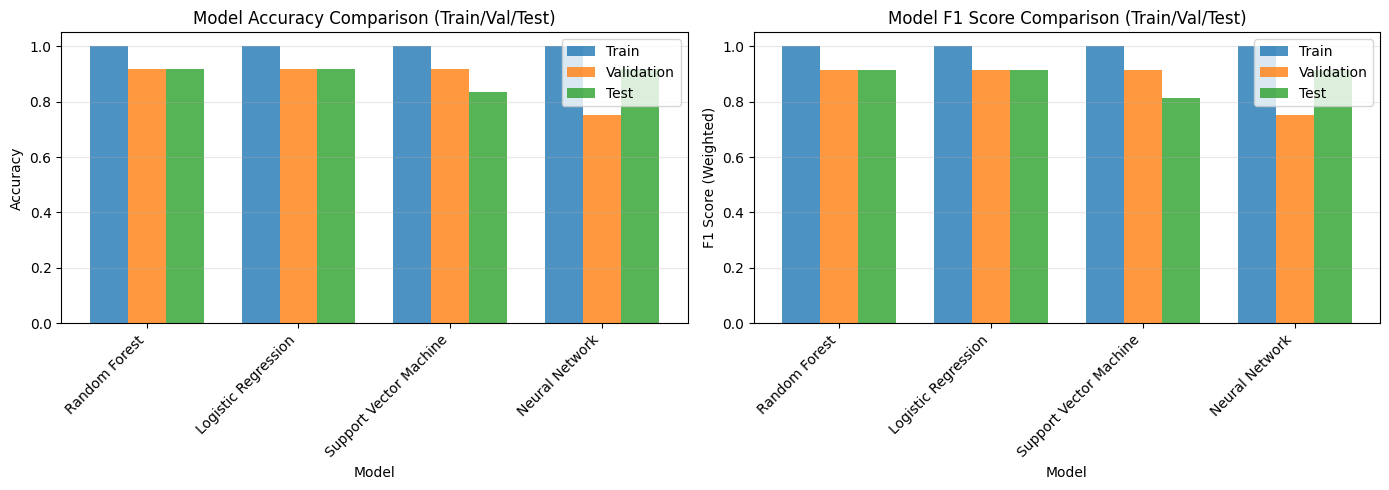

Visualizations saved!


In [28]:
# Visualization: Model Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy across datasets
models = comparison_df['Model'].tolist()
x_pos = np.arange(len(models))
width = 0.25

axes[0].bar(x_pos - width, comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
axes[0].bar(x_pos, comparison_df['Val Accuracy'], width, label='Validation', alpha=0.8)
axes[0].bar(x_pos + width, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison (Train/Val/Test)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: F1 Score comparison
axes[1].bar(x_pos - width, comparison_df['Train F1'], width, label='Train', alpha=0.8)
axes[1].bar(x_pos, comparison_df['Val F1'], width, label='Validation', alpha=0.8)
axes[1].bar(x_pos + width, comparison_df['Test F1'], width, label='Test', alpha=0.8)

axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_title('Model F1 Score Comparison (Train/Val/Test)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations saved!")

### Detailed Classification Reports

In [29]:
# Function to print detailed classification report
def print_detailed_report(y_true, y_pred, model_name, dataset_name):
    """Print detailed classification report including per-class metrics"""
    print(f"\n{'='*70}")
    print(f"{model_name} - {dataset_name} Set Classification Report")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred))

# Get predictions for all models on test set
print("\n\n" + "="*80)
print("DETAILED TEST SET ANALYSIS")
print("="*80)

# Random Forest
rf_test_pred = rf_model.predict(X_test)
print_detailed_report(y_test, rf_test_pred, "Random Forest", "Test")

# Logistic Regression
lg_test_pred = lg_model.predict(X_test_scaled)
print_detailed_report(y_test, lg_test_pred, "Logistic Regression", "Test")

# SVM
svm_test_pred = svm_model.predict(X_test_scaled)
print_detailed_report(y_test, svm_test_pred, "Support Vector Machine", "Test")

# Neural Network
print_detailed_report(y_test, y_test_pred_labels, "Neural Network", "Test")



DETAILED TEST SET ANALYSIS

Random Forest - Test Set Classification Report
                      precision    recall  f1-score   support

colonialwilliamsburg       1.00      0.75      0.86         4
           instagram       0.80      1.00      0.89         4
              target       1.00      1.00      1.00         4

            accuracy                           0.92        12
           macro avg       0.93      0.92      0.92        12
        weighted avg       0.93      0.92      0.92        12


Logistic Regression - Test Set Classification Report
                      precision    recall  f1-score   support

colonialwilliamsburg       1.00      0.75      0.86         4
           instagram       0.80      1.00      0.89         4
              target       1.00      1.00      1.00         4

            accuracy                           0.92        12
           macro avg       0.93      0.92      0.92        12
        weighted avg       0.93      0.92      0.92       

### Confusion Matrices

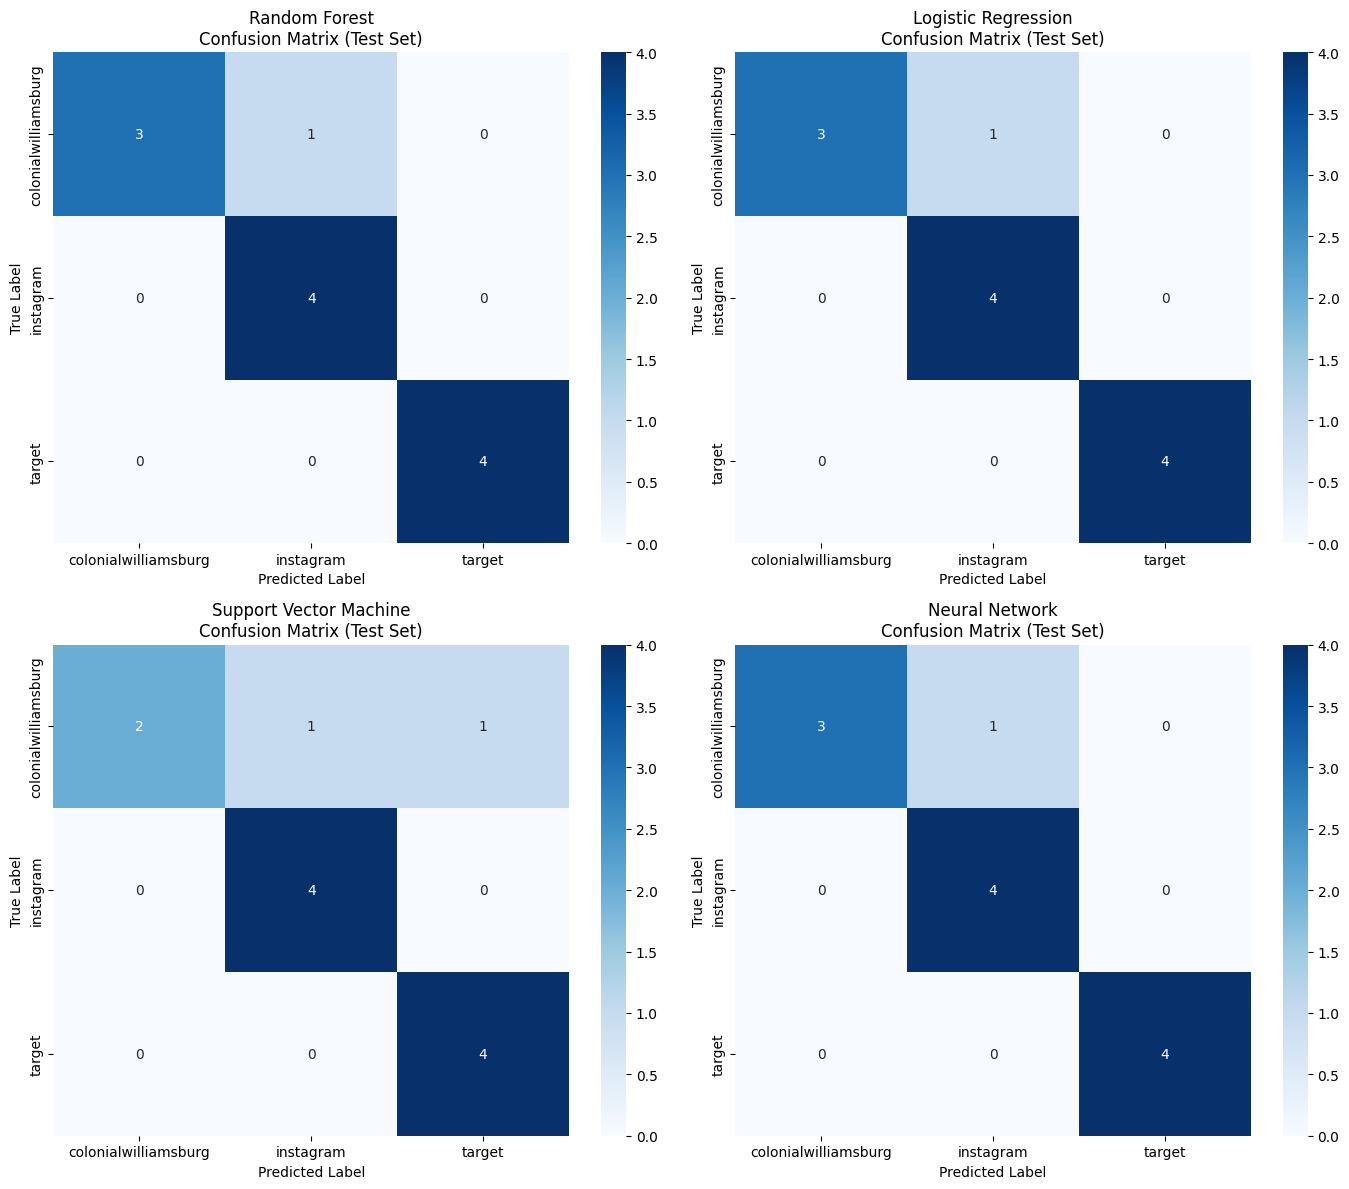

Confusion matrices generated!


In [30]:
# Visualize confusion matrices for best performing models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Get predictions
predictions = {
    'Random Forest': rf_test_pred,
    'Logistic Regression': lg_test_pred,
    'Support Vector Machine': svm_test_pred,
    'Neural Network': y_test_pred_labels
}

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    ax.set_title(f'{model_name}\nConfusion Matrix (Test Set)')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Confusion matrices generated!")

## Summary and Recommendations

In [31]:
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

# Find best model by test accuracy
best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_test_acc = comparison_df.loc[best_model_idx, 'Test Accuracy']

print(f"\n✓ BEST PERFORMING MODEL: {best_model_name}")
print(f"  Test Accuracy: {best_test_acc:.4f}")

# Check for overfitting/underfitting
print("\n✓ OVERFITTING/UNDERFITTING ANALYSIS:")
for idx, row in comparison_df.iterrows():
    train_acc = row['Train Accuracy']
    test_acc = row['Test Accuracy']
    gap = train_acc - test_acc
    model_name = row['Model']
    
    if gap > 0.1:
        status = "OVERFITTING DETECTED"
    elif gap < -0.05:
        status = "UNDERFITTING DETECTED"
    else:
        status = "GOOD GENERALIZATION"
    
    print(f"  {model_name:25s}: Gap={gap:.4f} -> {status}")

print("\n✓ KEY OBSERVATIONS:")
print(f"  - Number of classes: {len(label_encoder.classes_)}")
print(f"  - Training set size: {len(X_train)}")
print(f"  - Validation set size: {len(X_val)}")
print(f"  - Test set size: {len(X_test)}")
print(f"  - Number of features: {X_train.shape[1]}")

print("\n✓ RECOMMENDATIONS FOR IMPROVEMENT:")
recommendations = [
    "1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV for better parameters",
    "2. Feature Engineering: Create new features or perform feature selection",
    "3. Class Balancing: Check if classes are imbalanced and use appropriate techniques",
    "4. Ensemble Methods: Combine multiple models (voting, stacking) for better performance",
    "5. Deep Learning: Try more complex neural architectures (Conv1D, LSTM, Attention)",
    "6. Cross-Validation: Implement k-fold cross-validation for robust evaluation"
]

for rec in recommendations:
    print(f"  {rec}")


ANALYSIS SUMMARY

✓ BEST PERFORMING MODEL: Random Forest
  Test Accuracy: 0.9167

✓ OVERFITTING/UNDERFITTING ANALYSIS:
  Random Forest            : Gap=0.0833 -> GOOD GENERALIZATION
  Logistic Regression      : Gap=0.0833 -> GOOD GENERALIZATION
  Support Vector Machine   : Gap=0.1667 -> OVERFITTING DETECTED
  Neural Network           : Gap=0.0833 -> GOOD GENERALIZATION

✓ KEY OBSERVATIONS:
  - Number of classes: 3
  - Training set size: 36
  - Validation set size: 12
  - Test set size: 12
  - Number of features: 11

✓ RECOMMENDATIONS FOR IMPROVEMENT:
  1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV for better parameters
  2. Feature Engineering: Create new features or perform feature selection
  3. Class Balancing: Check if classes are imbalanced and use appropriate techniques
  4. Ensemble Methods: Combine multiple models (voting, stacking) for better performance
  5. Deep Learning: Try more complex neural architectures (Conv1D, LSTM, Attention)
  6. Cross-Validatio